# Classificação Supervisionada

## 1. Introdução



## 2. Importação das Bibliotecas Necessárias

Neste bloco de código são importadas as bibliotecas utilizadas ao longo do desenvolvimento do trabalho. Estas bibliotecas permitem a manipulação e análise de dados, a implementação de modelos de *Machine Learning*, a visualização gráfica dos resultados e a avaliação do desempenho dos classificadores.

As bibliotecas `pandas` e `numpy` são utilizadas para o tratamento e manipulação de dados, permitindo uma gestão eficiente das estruturas de dados. As bibliotecas `matplotlib` e `seaborn` são utilizadas para a criação de representações gráficas, facilitando a interpretação dos resultados obtidos.

Relativamente aos métodos de *Machine Learning*, são importadas funcionalidades do `scikit-learn`, nomeadamente ferramentas para a divisão dos dados em conjuntos de treino e teste, normalização dos atributos, métricas de avaliação e algoritmos de classificação. Entre os modelos utilizados destacam-se a *Decision Tree*, o *Random Forest* e a *Neural Network (MLP)*.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


## 3. Carregamento e Preparação do Conjunto de Dados

Neste bloco de código é realizado o carregamento do conjunto de dados previamente preparado, recorrendo à função `read_csv`. O ficheiro utilizado resulta do processo de *Exploratory Data Analysis (EDA)* e de pré-processamento efectuado anteriormente, garantindo que os dados se encontram prontos para a fase de modelação.

Após o carregamento dos dados, procede-se à separação entre as variáveis independentes (*features*) e a variável dependente (*target*). As *features* correspondem a todos os atributos do conjunto de dados, enquanto a variável *target* representa a classe a prever.

Esta separação é essencial para a aplicação de algoritmos de classificação supervisionada, permitindo treinar e avaliar os modelos de forma adequada.


In [41]:
df = pd.read_csv("data/prepared_classification.csv")

X = df.drop("class", axis=1)
y = df["class"]


### 4. Visualização Exploratória das Features

Neste bloco de código é realizada uma **análise exploratória visual** do conjunto de dados, recorrendo a um *pairplot*. Para esse efeito, as *features* são combinadas com a variável alvo (*class*), permitindo analisar simultaneamente a relação entre pares de variáveis e a sua distribuição individual.

O *pairplot* apresenta, para cada par de *features*, um gráfico de dispersão, enquanto nas diagonais são representadas as distribuições de cada variável sob a forma de histogramas. As instâncias são diferenciadas por cor de acordo com a classe a que pertencem, facilitando a observação de padrões, separações entre classes e possíveis sobreposições.

Esta visualização permite identificar relações entre variáveis, avaliar a separabilidade das classes e detectar possíveis redundâncias ou correlações entre *features*, constituindo uma etapa importante da análise exploratória dos dados.


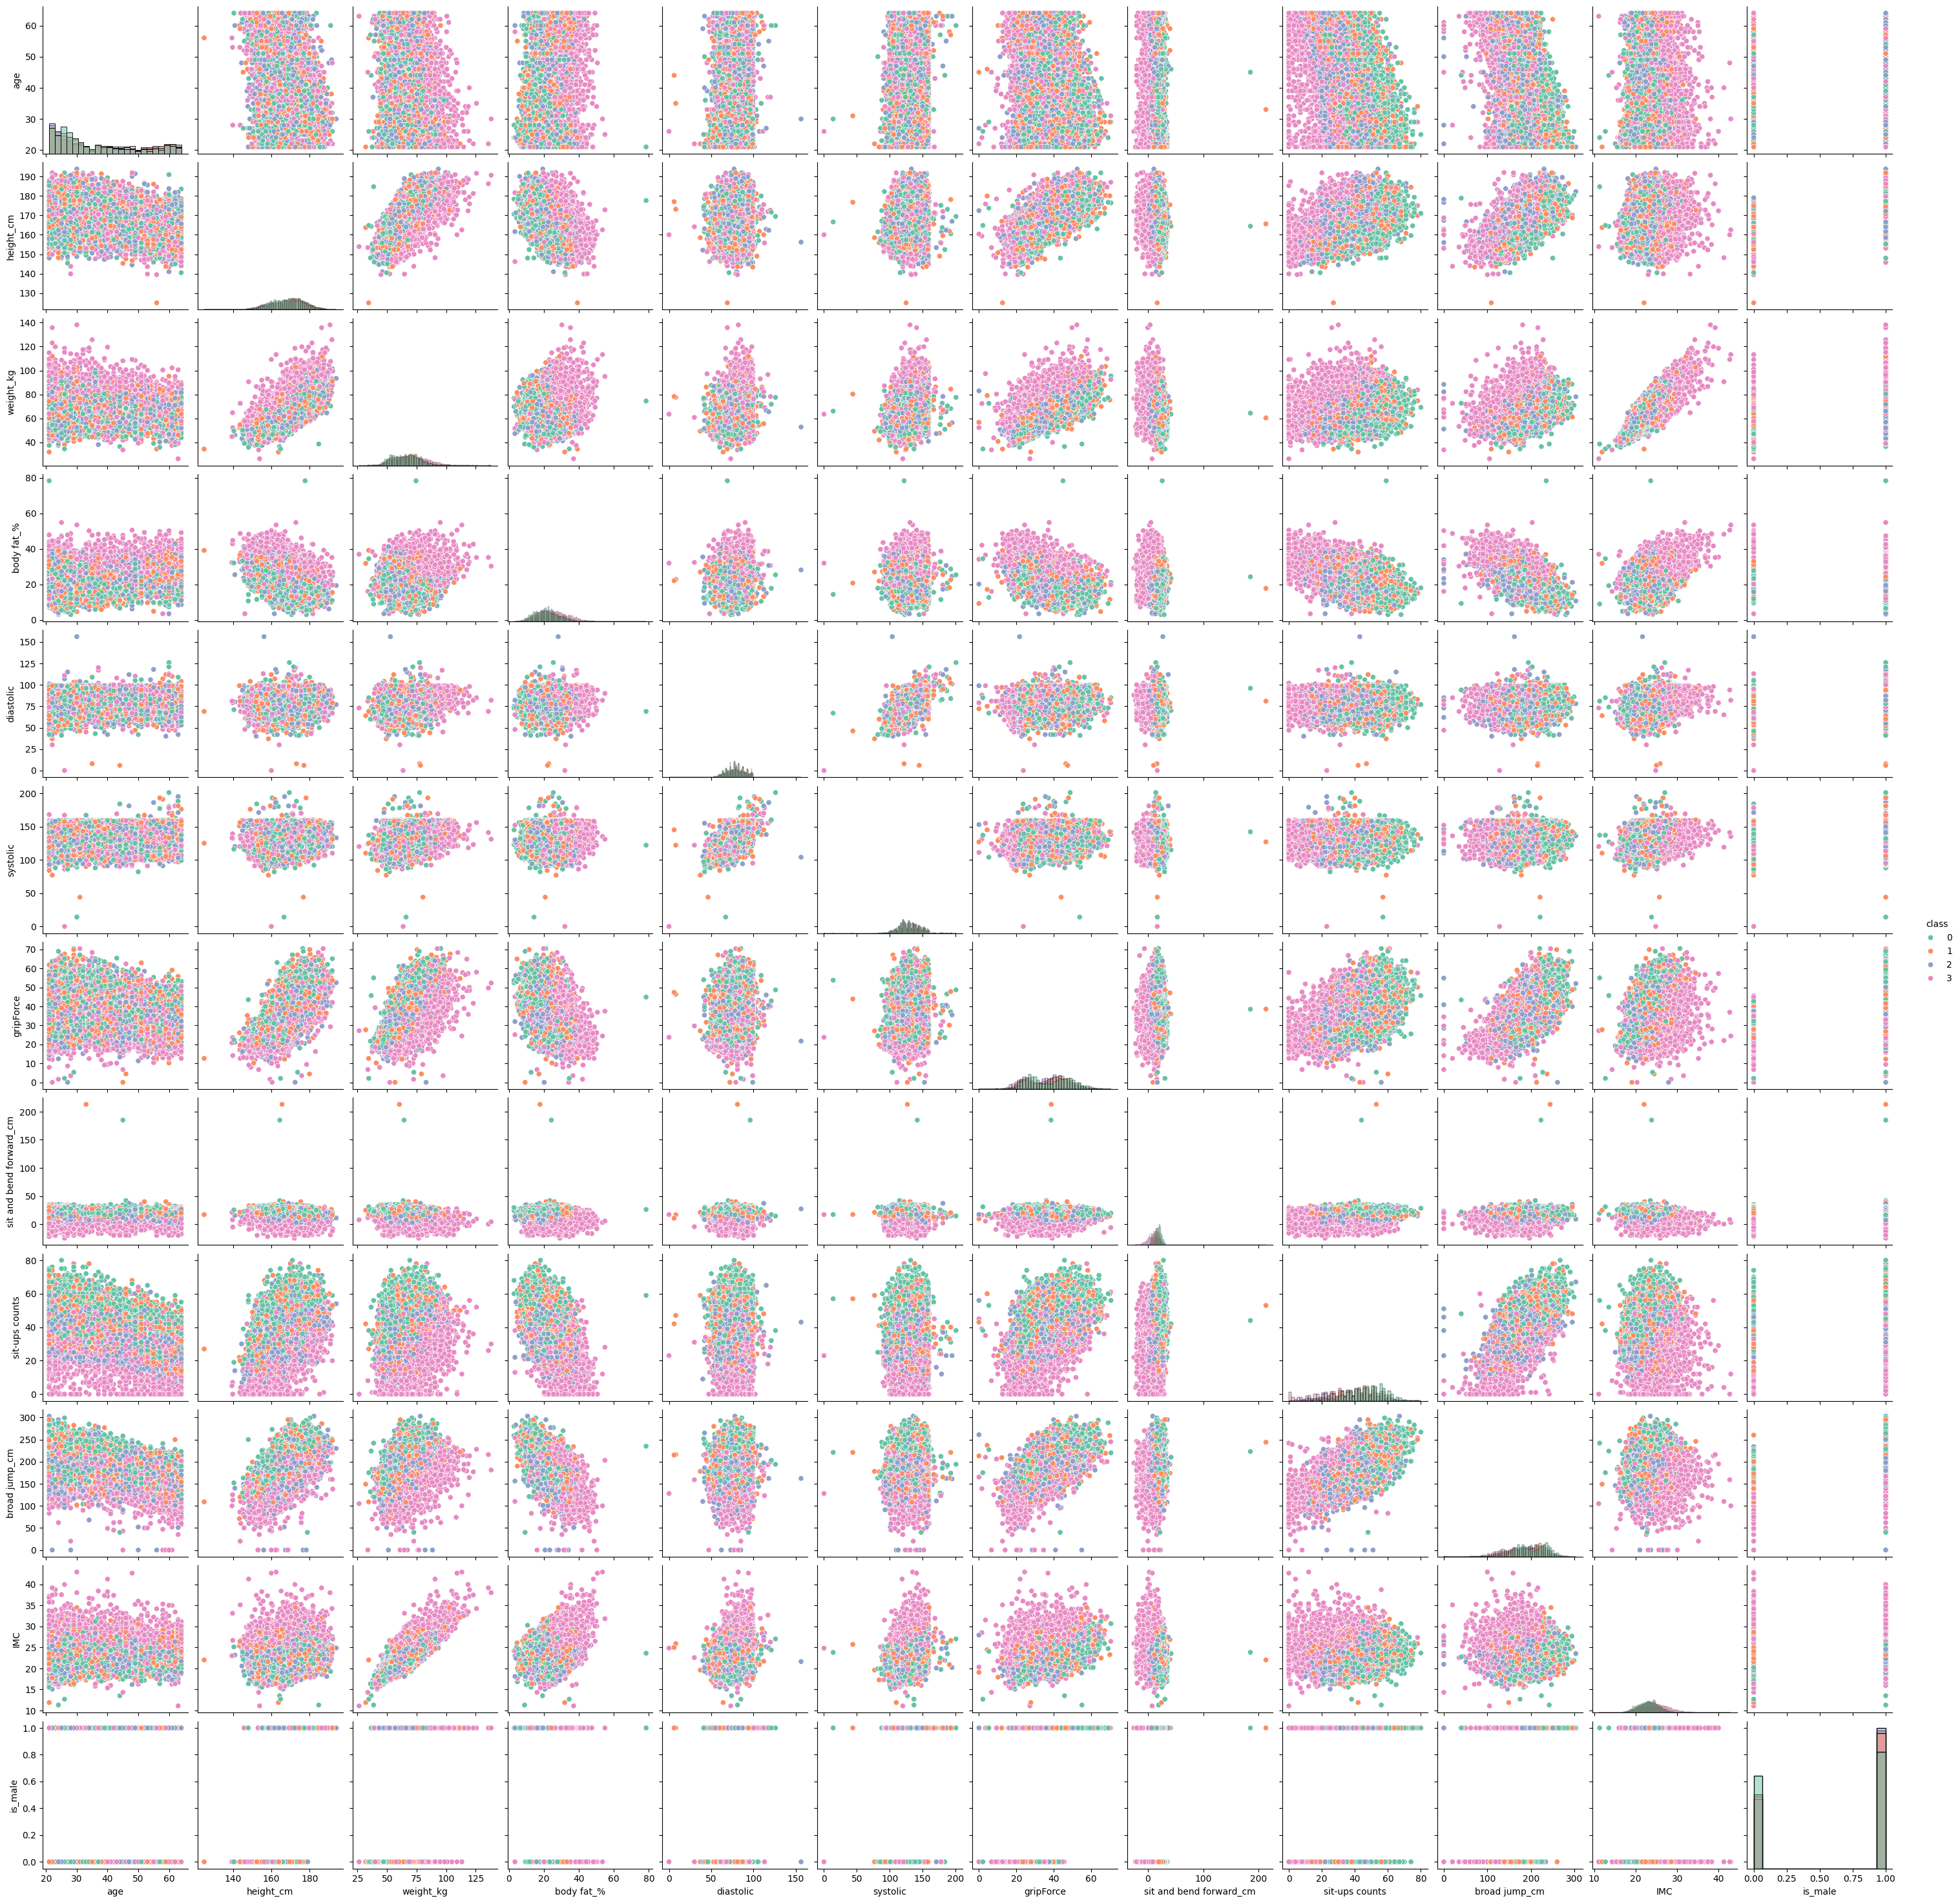

In [ ]:
#df_vis = X.copy()
#df_vis["class"] = y

#sns.pairplot(
#    df_vis,
#    hue="class",
#    palette="Set2",
#    diag_kind="hist"
#)
#plt.show()

## 5. Divisão dos Dados em Conjuntos de Treino e Teste

Neste bloco de código é efectuada a divisão do conjunto de dados em **conjuntos de treino e de teste**, recorrendo à função `train_test_split`. É utilizada uma proporção de 80% dos dados para treino e 20% para teste, uma prática comum em problemas de classificação.

O parâmetro `random_state` é definido para garantir a reprodutibilidade dos resultados, assegurando que a divisão dos dados é consistente entre diferentes execuções do código.

Adicionalmente, é utilizado o parâmetro `stratify=y`, o qual garante que a distribuição das classes é mantida de forma proporcional em ambos os conjuntos. Esta abordagem é particularmente importante em problemas de classificação, uma vez que contribui para uma avaliação mais justa e fiável do desempenho dos modelos.


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Normalização dos Dados

Neste bloco de código é aplicada a **normalização dos dados** utilizando o `StandardScaler`. Esta técnica transforma os atributos de forma a apresentarem média zero e desvio padrão unitário, o que é particularmente relevante para algoritmos sensíveis à escala das variáveis de entrada.

O processo de normalização é ajustado exclusivamente com base no conjunto de treino, através do método `fit_transform`, de modo a evitar *data leakage*. Posteriormente, a mesma transformação é aplicada ao conjunto de teste utilizando o método `transform`, garantindo consistência entre ambos os conjuntos.

Esta abordagem contribui para um melhor desempenho dos modelos, especialmente no caso de algoritmos como *Neural Networks*, onde a escala dos dados tem um impacto significativo no processo de aprendizagem.


In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Definição dos Modelos de Classificação

Neste bloco de código são definidos os diferentes **modelos de classificação supervisionada** utilizados no estudo, permitindo efectuar uma análise comparativa do seu desempenho. A utilização de múltiplos algoritmos possibilita avaliar abordagens distintas de *Machine Learning*, incluindo modelos baseados em árvores de decisão, métodos de conjunto (*ensemble*) e redes neuronais artificiais.

O **Decision Tree Classifier** é configurado com uma profundidade máxima limitada, de forma a controlar a complexidade do modelo e reduzir o risco de *overfitting*. Este modelo apresenta ainda a vantagem de ser facilmente interpretável, permitindo compreender o processo de decisão adotado.

O **Random Forest Classifier** consiste num método de conjunto baseado em múltiplas árvores de decisão, combinando as previsões individuais de cada árvore de forma a obter resultados mais robustos e estáveis. O número de árvores e a profundidade máxima são definidos de modo a equilibrar o desempenho do modelo com o custo computacional associado.

Por fim, o **Multi-Layer Perceptron (MLP)** representa uma *Neural Network* com múltiplas camadas ocultas. A utilização da função de activação *ReLU* e do optimizador *Adam* permite uma aprendizagem eficiente, especialmente em problemas de classificação mais complexos. O número máximo de iterações é definido de forma a assegurar a convergência do modelo durante o processo de treino.

Em todos os modelos é fixado o parâmetro `random_state`, garantindo a reprodutibilidade dos resultados obtidos.


In [45]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42
    ),
    
    "Neural Net": MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )
}


## 8. Treino, Previsão e Avaliação dos Modelos

Neste bloco de código é realizado o **treino dos modelos de classificação**, seguido da **realização de previsões** e da **avaliação do seu desempenho**. Este processo é efectuado de forma iterativa para cada um dos modelos previamente definidos, permitindo uma comparação sistemática e consistente dos resultados obtidos.

No caso do modelo de **Rede Neuronal Artificial (MLP)**, são utilizados os dados previamente normalizados, uma vez que este tipo de algoritmo é particularmente sensível à escala dos atributos. Em contraste, os modelos baseados em árvores de decisão (*Decision Tree* e *Random Forest*) são treinados e avaliados utilizando os dados não normalizados, dado que não dependem da escala das variáveis de entrada.

Após o treino de cada modelo, são geradas previsões sobre o conjunto de teste. De seguida, é calculada a métrica de **accuracy**, a qual é armazenada para posterior análise comparativa entre os diferentes modelos.

Adicionalmente, é apresentado o **classification report**, que inclui métricas como precisão, *recall* e *F1-score* para cada classe. Este relatório permite uma avaliação mais detalhada do desempenho dos modelos, contribuindo para uma análise mais aprofundada do seu comportamento.


In [46]:
results = {}

for name, model in models.items():
    
    if name == "Neural Net":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n {name}")
    print(classification_report(y_test, y_pred))



 Decision Tree
              precision    recall  f1-score   support

           0       0.68      0.85      0.75       670
           1       0.53      0.60      0.56       669
           2       0.73      0.56      0.63       670
           3       0.90      0.76      0.82       670

    accuracy                           0.69      2679
   macro avg       0.71      0.69      0.69      2679
weighted avg       0.71      0.69      0.69      2679


 Random Forest
              precision    recall  f1-score   support

           0       0.71      0.88      0.78       670
           1       0.64      0.56      0.60       669
           2       0.73      0.71      0.72       670
           3       0.91      0.83      0.87       670

    accuracy                           0.75      2679
   macro avg       0.75      0.75      0.74      2679
weighted avg       0.75      0.75      0.74      2679


 Neural Net
              precision    recall  f1-score   support

           0       0.73      0

## 9. Análise das Matrizes de Confusão

A matriz de confusão fornece uma visão detalhada dos resultados obtidos pelos classificadores, evidenciando os verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos. Esta representação permite analisar a correspondência entre as classes reais e as classes preditas para cada um dos modelos considerados.

Através da visualização das matrizes de confusão sob a forma de *heatmaps*, torna-se possível identificar padrões de erro, avaliar quais as classes mais frequentemente confundidas e compreender de forma mais aprofundada o comportamento dos modelos. Esta análise complementa as métricas quantitativas apresentadas anteriormente, contribuindo para uma avaliação mais completa do desempenho dos classificadores.


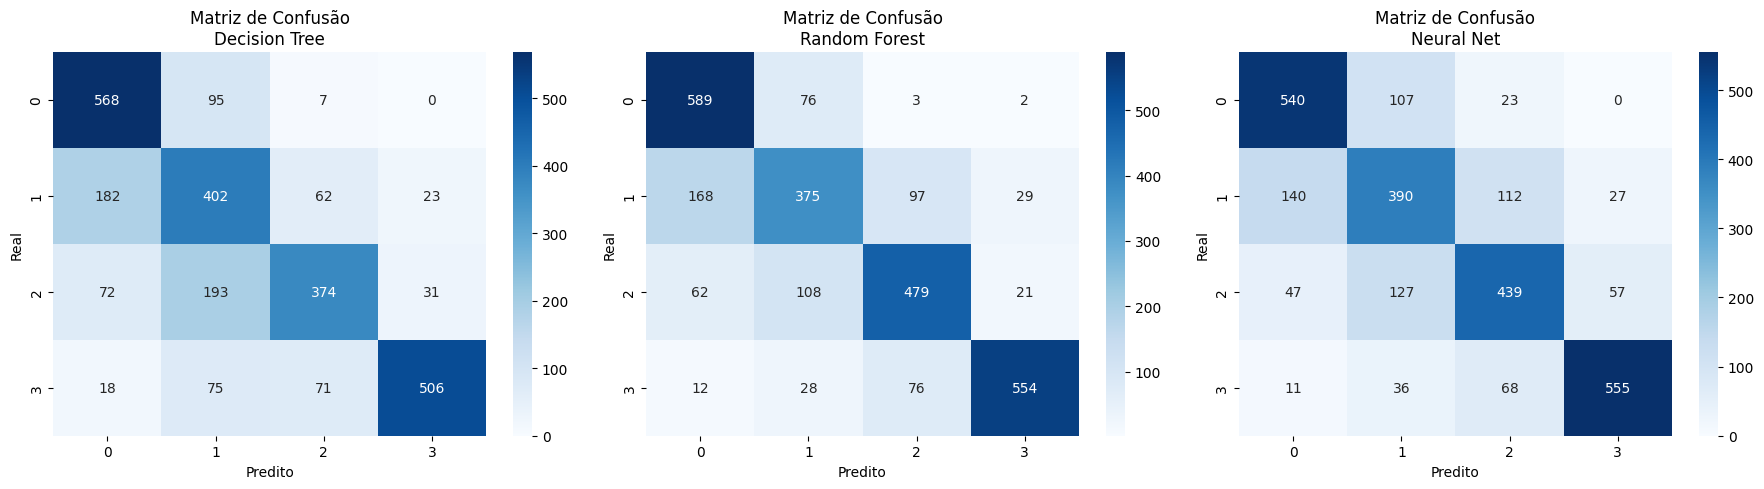

In [47]:
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    
    plt.subplot(1, 3, i + 1)
    
    if name == "Neural Net":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title(f"Matriz de Confusão\n{name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")

plt.tight_layout()
plt.show()


## 10. Comparação do Desempenho dos Modelos

Neste bloco de código é realizada uma **comparação gráfica do desempenho dos modelos de classificação**, utilizando a métrica de **accuracy**. Os valores de desempenho previamente calculados são representados através de um gráfico de barras, permitindo uma análise visual direta das diferenças entre os modelos considerados.

Esta representação gráfica permite identificar de forma imediata o modelo com melhor desempenho global, complementando a análise quantitativa efectuada anteriormente e contribuindo para uma discussão mais fundamentada dos resultados obtidos.


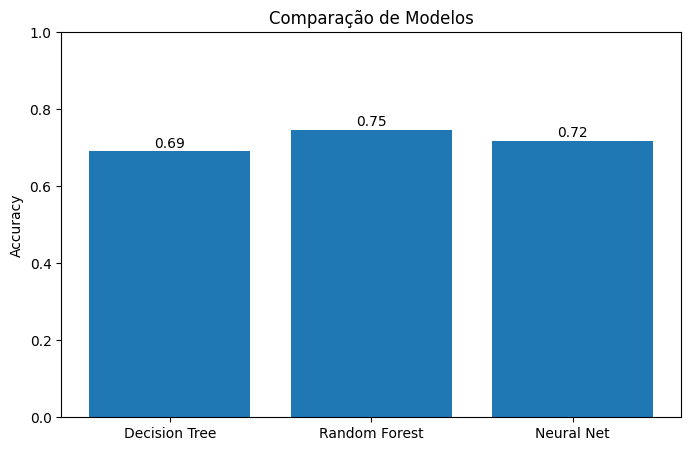

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(
    results.keys(),
    results.values()
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparação de Modelos")

for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


## 11. Cross-Validation

Neste bloco de código é realizada a **avaliação do desempenho do modelo**, recorrendo à técnica de *Stratified K-Fold*. Esta abordagem permite obter uma estimativa mais robusta e fiável do desempenho do modelo, reduzindo a dependência de uma única divisão dos dados em conjuntos de treino e teste.

O Cross-Validation é configurada com cinco partições (*folds*), sendo aplicada a aleatorização dos dados de forma controlada, garantindo a reprodutibilidade dos resultados. A utilização de uma estratégia estratificada assegura que a distribuição das classes se mantém proporcional em cada *fold*, o que é particularmente importante em problemas de classificação.

O classificador **Random Forest** é avaliado utilizando a métrica de **accuracy**. No final, são apresentados a média e o desvio padrão das exactidões obtidas nos diferentes *folds*, fornecendo uma medida do desempenho médio do modelo e da sua estabilidade ao longo das diferentes partições.


In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=False)

scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV Accuracy:", scores.mean(), "+/-", scores.std())


CV Accuracy: 0.7362800761935347 +/- 0.005759773589004821


## 11. Distribuição das Features Mais Relevantes

Com base na importância das *features* obtida a partir do modelo **Random Forest** definido anteriormente, procede-se à análise da distribuição das variáveis mais influentes no processo de classificação. A análise da *feature importance* permite identificar quais os atributos que mais contribuem para as decisões do modelo.

Neste bloco de código é utilizado o modelo **Random Forest** previamente treinado, com hyperparameters definidos manualmente. Antes de calcular a importância das *features*, é garantido que o modelo se encontra devidamente ajustado aos dados de treino.

As importâncias das variáveis são calculadas e ordenadas de forma decrescente, sendo seleccionadas as três *features* mais relevantes. Para estas variáveis, são gerados histogramas que permitem analisar a sua distribuição ao longo do conjunto de dados.

Esta visualização contribui para uma melhor compreensão do impacto das *features* mais relevantes no processo de classificação e para uma interpretação mais aprofundada do comportamento do modelo, complementando a análise quantitativa do desempenho apresentada anteriormente.


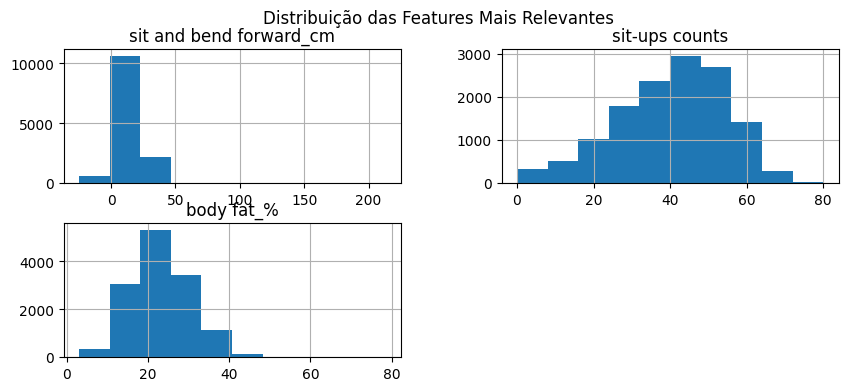

In [50]:
# Utilização do modelo Random Forest definido anteriormente
rf_estimator = models["Random Forest"]

# Garantir que o modelo se encontra treinado antes de aceder às feature importances
if not hasattr(rf_estimator, "feature_importances_"):
    rf_estimator.fit(X_train, y_train)

# Cálculo da importância das features
fi = pd.Series(
    rf_estimator.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Selecção das três features mais relevantes
top_features = fi.head(3).index

# Visualização da distribuição das features mais relevantes
df[top_features].hist(figsize=(10, 4))
plt.suptitle("Distribuição das Features Mais Relevantes")
plt.show()
